## Imports

In [12]:
TRACE_OUT_FOLDER = "trace_output/"
DETECTOR = "NaIR"
DET_NAME_PGRAD = "LU_NaIR"
DET_EFF = 0.0261

In [32]:
from pathlib import Path
import json
import time
import sys

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import yaml
import arviz as az

from matplotlib import pyplot as plt
import matplotlib.patches as patches

# src directory
parent_dir = Path.cwd().parent.parent 
sys.path.append(str(parent_dir))
print(parent_dir)

from run_model import run
from tools.myutils import plot_act_density, plot_location

/home/pim/pg-rad-analysis/src


In [33]:
def get_sim_path_and_csv_name(i, base_dir="output"):
    base_path = Path(base_dir)
    # Find all directories matching the pattern f"{i}_result_*"
    folders = list(base_path.glob(f"{i}_result_*"))
    if not folders:
        raise FileNotFoundError(f"No folder matching {i}_result_* found in {base_dir}")

    folder_name = folders[0].name
    print("Detected folder name:", folder_name)

    # Find all CSV files in the folder
    csv_files = list(folders[0].glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV file found in {folders[0]}")

    csv_name = csv_files[0].name
    print("Detected CSV name:", csv_name)

    return str(folders[0]), csv_name

## Create configs

We create 2 configs, one with the source along a straight road and another at the center point of a 90 degree turn.

In [34]:
with open('base_config.yml') as f:
    conf = yaml.safe_load(f)

conf

{'name': 'no bend',
 'speed': 8.33,
 'acquisition_time': 1,
 'path': {'length': [100, 150, 100, 150],
  'segments': [{'turn_left': 45}, 'straight', 'straight', 'straight']},
 'sources': {'s1': {'activity_MBq': 100,
   'isotope': 'Cs137',
   'gamma_energy_keV': 662,
   'position': {'along_path': 308.33,
    'dist_from_path': 63.666667,
    'side': 'left'}}},
 'detector': 'LU_NaIR',
 'options': {'bkg_cps': 0}}

In [1]:
with open('tmp.yml', 'w') as f:
    yaml.dump(conf, f, default_flow_style=False)
! cd pgrad_output && pgrad --config ../tmp.yml --save

NameError: name 'yaml' is not defined

In [36]:
conf['name'] = 'with bend'
conf['path'] = {'length': [100, 150, 100, 150], 'segments': [{'turn_left': 45}, 'straight', {'turn_left': 90}, 'straight']}
conf

{'name': 'with bend',
 'speed': 8.33,
 'acquisition_time': 1,
 'path': {'length': [100, 150, 100, 150],
  'segments': [{'turn_left': 45}, 'straight', {'turn_left': 90}, 'straight']},
 'sources': {'s1': {'activity_MBq': 100,
   'isotope': 'Cs137',
   'gamma_energy_keV': 662,
   'position': {'along_path': 308.33,
    'dist_from_path': 63.666667,
    'side': 'left'}}},
 'detector': 'LU_NaIR',
 'options': {'bkg_cps': 0}}

In [37]:
with open('tmp.yml', 'w') as f:
    yaml.dump(conf, f, default_flow_style=False)
! cd pgrad_output && pgrad --config ../tmp.yml --save

2026-05-16 17:40:40,823 - INFO: Landscape built successfully: with bend
<class 'numpy.bool'>
2026-05-16 17:40:40,831 - INFO: Simulation output saved to with_bend_result_20260516_1740!


## Fit Bayesian model

In [39]:
for i in ['no_bend', 'with_bend']:
    csv_path, roi_filename = get_sim_path_and_csv_name(i, base_dir='pgrad_output')
    
    BASE_DIR = Path("__file__").resolve().parent
    CSV_DIR = Path(BASE_DIR.joinpath(csv_path))

    params_file = Path(CSV_DIR.joinpath("parameters.json"))
    params = json.load(params_file.open())

    csv_file = Path(CSV_DIR.joinpath(roi_filename))
    df = pd.read_csv(csv_file)

    df['ROI_BR'] += 30
    df['ROI_P'] += df['ROI_BR']

    for j in range(10):
        trace, real_params = run(df, params, csv_file, DETECTOR, DET_EFF, n_sources = 1)
        az.to_netcdf(trace, filename=TRACE_OUT_FOLDER+str(i)+"_trace_"+str(j))
        df.to_pickle(TRACE_OUT_FOLDER+str(i)+"_pkl_"+str(j))
    
        with open(TRACE_OUT_FOLDER+str(i)+"_real_params_"+str(j),'w') as fp:
            json.dump(real_params, fp)

Detected folder name: no_bend_result_20260516_1740
Detected CSV name: 1_1_src_0_cps_bkg_100MBq_64m_201_230.csv


/home/pim/miniforge3/envs/pg-rad-analysis/lib/python3.12/site-packages/pymc/sampling/mcmc.py:786: UserWarning: A list or tuple of random_seed no longer specifies the specific random_seed of each chain. Use a single seed instead.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [y_src, x_src, act_src]


Output()

Sampling 2 chains for 500 tune and 2_000 draw iterations (1_000 + 4_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [predicted_cps]


Output()

...

Output()

/home/pim/miniforge3/envs/pg-rad-analysis/lib/python3.12/site-packages/pymc/sampling/mcmc.py:786: UserWarning: A list or tuple of random_seed no longer specifies the specific random_seed of each chain. Use a single seed instead.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [y_src, x_src, act_src]


Output()

Sampling 2 chains for 500 tune and 2_000 draw iterations (1_000 + 4_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [predicted_cps]


Output()

## Trace Analysis

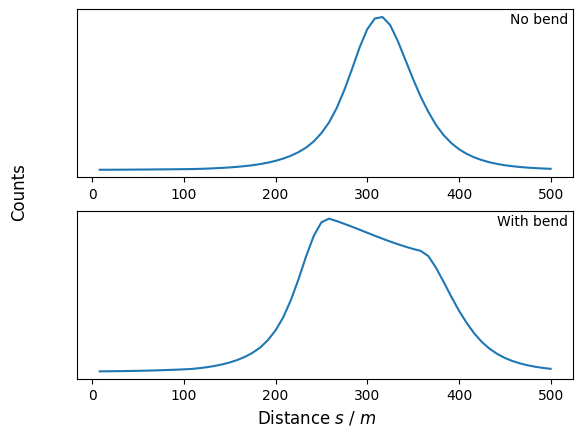

In [46]:
result_dict = {}
fig, axs = plt.subplots(len(['no_bend', 'with_bend']))
fig.supxlabel('Distance $s$ / $m$')
fig.supylabel('Counts')

for i, sim in enumerate(['no_bend', 'with_bend']):
    traces = []
    for j in range(10):
        traces.append(az.from_netcdf(f"trace_output/{sim}_trace_{j}"))
        df_i = pd.read_pickle(f"trace_output/{sim}_pkl_{j}")
        with open(f"trace_output/{sim}_real_params_{j}", 'r') as file:
            real_params = json.load(file)
        real_params_i = {int(k):v for k,v in real_params.items()}

    axs[i].plot(df_i["Dist"], df_i["ROI_P"])
    axs[i].text(0.99, 0.98, str(sim).replace('_', ' ').capitalize(), transform=axs[i].transAxes, ha='right', va='top')
    axs[i].set_yticks([])

    result_dict[sim] = {'traces': traces, 'df': df_i, 'real_params': real_params_i}

plt.savefig('bend-vs-no-bend-plot.png')

In [50]:
ard_list = []
rpd_list = []

for sim in ['no_bend', 'with_bend']:
    rp = result_dict[sim]['real_params']
    
    real_acts = np.array([rp[1]['act']]).T
    real_x, real_y = np.array([rp[1]['x']]).T, np.array([rp[1]['y']]).T

    ard_ls = []
    rpd_ls = []
    
    for j in range(10):
        trace = result_dict[sim]['traces'][j]
        posterior = trace.posterior
        x_samples = posterior.x_src.stack(sample=("chain","draw")).transpose("sources","sample").values
        y_samples = posterior.y_src.stack(sample=("chain","draw")).transpose("sources","sample").values
        a_samples = posterior.act_src.stack(sample=("chain","draw")).transpose("sources","sample").values
    
        x_mean = x_samples.mean(axis=1)
        y_mean = y_samples.mean(axis=1)
    
        r_real = np.sqrt(real_x**2 + real_y**2)
        r_est = np.sqrt(x_mean**2 + y_mean**2)
    
        act_mean = a_samples.mean(axis=1)
    
        ARD = np.abs(act_mean - real_acts) / real_acts * 100
        RPD = np.abs(r_est - r_real) / r_real * 100
    
        ard_ls.append(ARD)
        rpd_ls.append(RPD)

    ard_list.append(ard_ls)
    rpd_list.append(rpd_ls)

ard_arr = np.array(ard_list)
rpd_arr = np.array(rpd_list)

In [61]:
print("mean(RPD) (no bend / bend):", rpd_arr.mean(axis=(1, 2)))
print("var(RPD) (no bend / bend):", rpd_arr.var(axis=(1, 2)))
print("mean(ARD) (no bend / bend):", ard_arr.mean(axis=(1, 2)))
print("var(ARD) (no bend / bend):", ard_arr.var(axis=(1, 2)))

mean(RPD) (no bend / bend): [3.2728918  1.84733597]
var(RPD) (no bend / bend): [3.80517773 0.58409385]
mean(ARD) (no bend / bend): [39.92329509 62.6016085 ]
var(ARD) (no bend / bend): [  4.69457192 125.77313216]


In [62]:
is_located = (ard_arr < 30) & (rpd_arr < 30)

print("RPD alone:", (rpd_arr < 30).sum(axis=(1, 2)) / 10)
print("ARD alone:", (ard_arr < 30).sum(axis=(1, 2)) / 10)

LP = is_located.sum(axis=(1, 2)) / 20
LP

RPD alone: [1. 1.]
ARD alone: [0. 0.]


array([0., 0.])

# Other

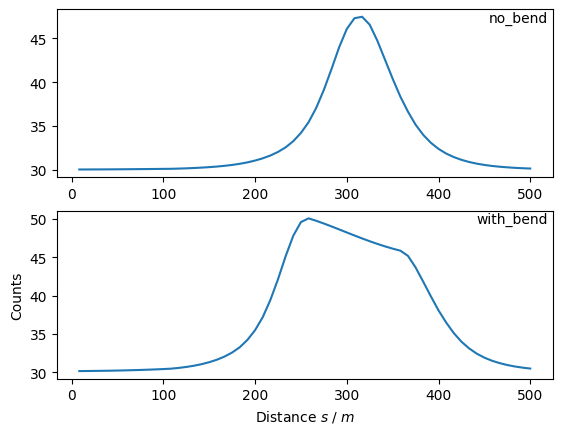

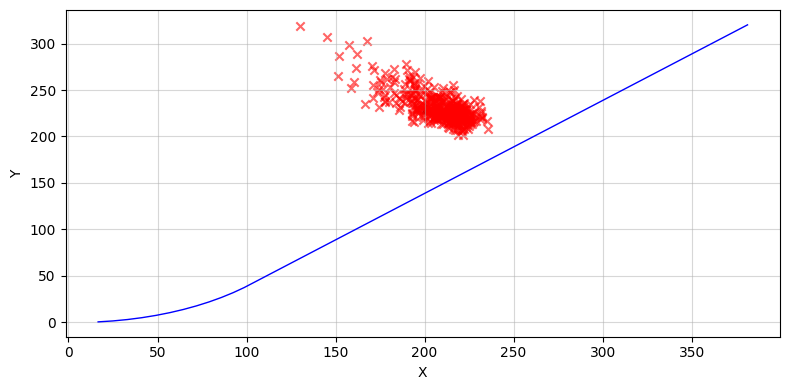

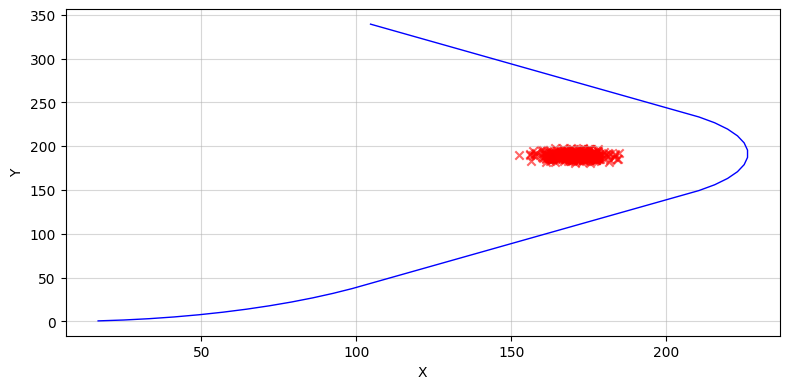

In [74]:
SIM_ID = ['no_bend', 'with_bend'] # [500, 300, 200, 150, 100, 75, 50, 25]
result_dict = {}

fig, axs = plt.subplots(len(SIM_ID))
plt.xlabel('Distance $s$ / $m$')
plt.ylabel('Counts')

j = 5
for i, sim in enumerate(SIM_ID):
    trace_i = az.from_netcdf(f"trace_output/{sim}_trace_{j}")
    df_i = pd.read_pickle(f"trace_output/{sim}_pkl_{j}")
    with open(f"trace_output/{sim}_real_params_{j}", 'r') as file:
        real_params = json.load(file)
    real_params_i = {int(k):v for k,v in real_params.items()}
    axs[i].plot(df_i["Dist"], df_i["ROI_P"], label=f'$d$ = {sim}')
    axs[i].text(.99, .99, str(sim), transform=axs[i].transAxes, ha='right', va='top')
    
    result_dict[sim] = {'trace': trace_i, 'df': df_i, 'real_params': real_params_i}

for k, v in result_dict.items():

    posterior = v['trace'].posterior
    n_sources = posterior.sizes["sources"]
    act_samples = {}
    
    for i in range(n_sources):
        act_samples[i+1] = (
            posterior["act_src"]
            .sel(sources=i)
            .values
            .reshape(-1)
        )
    
    x_samples = posterior.x_src.stack(sample=("chain","draw")).transpose("sources","sample").values
    y_samples = posterior.y_src.stack(sample=("chain","draw")).transpose("sources","sample").values

    ref_coords_x = [v['real_params'][j+1].get("x") for j in range(len(v['real_params']))]
    ref_coords_y = [v['real_params'][j+1].get("y") for j in range(len(v['real_params']))]

    plot_location(
        v['df'],
        ref_coords_x,
        ref_coords_y,
        x_samples,
        y_samples,
    )